<a href="https://colab.research.google.com/github/rercampos/data-science-projects/blob/main/An%C3%A1lise_de_S%C3%A9rie_Temporal_dos_Casos_Di%C3%A1rios_de_COVID_19_no_Brasil_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Análise de Série Temporal dos Casos Diários de COVID-19 no Brasil: Tendências, Oscilações e Média Móvel**

**Sobre a base de dados**

A base utilizada neste trabalho é o conjunto de dados sobre COVID-19 (COVID-19 Data), organizado e mantido pelo Our World in Data (OWID), projeto de pesquisa vinculado à Universidade de Oxford que reúne e disponibiliza publicamente estatísticas globais sobre a pandemia. Os dados são consolidados a partir de fontes oficiais, como organismos internacionais de saúde e autoridades nacionais, e cobrem indicadores de casos confirmados, óbitos, testagem, vacinação e hospitalizações para diversos países. Trata-se de uma importante fonte pública para estudos de epidemiologia e saúde pública.
A base possui uma linha para cada combinação de país e data, o que a torna adequada para análises de séries temporais. Além dos indicadores da pandemia, ela traz variáveis de contexto, como população, faixa etária e indicadores econômicos e de saúde de cada país, o que permite comparações entre diferentes localidades.
Neste trabalho será utilizado o recorte referente ao Brasil, obtido por meio do filtro location == "Brazil". A variável temporal utilizada é a data (date), com frequência diária, e a variável analisada é o número de novos casos confirmados por dia (new_cases). O recorte contém aproximadamente [número de registros] observações, cobrindo o período de [data inicial] a [data final].





**Acesso à base de dados**

Os dados foram obtidos diretamente do repositório oficial do Our World in Data, e não de uma base reproduzida por plataformas de terceiros. Para acessá-los, foram seguidas as seguintes etapas:

Fonte: Our World in Data – COVID-19 Data

Repositório: https://github.com/owid/covid-19-data

Arquivo: owid-covid-data.csv (conjunto completo, em formato CSV)

Filtro aplicado: location == "Brazil"

Variável temporal: date (frequência diária)

Variável analisada: new_cases (novos casos confirmados por dia)



**Importação das Bibliotecas**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

**Carregamento da Base de Dados**

In [ ]:
import pandas as pd

# Leitura direta do repositório do OWID (arquivo "raw")
URL = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"

df = pd.read_csv(URL, usecols=["location", "date", "new_cases"],
                 parse_dates=["date"])

# Filtra o Brasil e ordena cronologicamente
df = df[df["location"] == "Brazil"].sort_values("date").reset_index(drop=True)

print("Registros:", len(df))
print("Período:", df["date"].min().date(), "a", df["date"].max().date())

print("\nIntervalos entre datas:")
print(df["date"].diff().value_counts().head())

print("\nValores ausentes em new_cases:", df["new_cases"].isna().sum())
print(df.head())

Registros: 1674
Período: 2020-01-05 a 2024-08-04

Intervalos entre datas:
date
1 days    1673
Name: count, dtype: int64

Valores ausentes em new_cases: 0
  location       date  new_cases
0   Brazil 2020-01-05        0.0
1   Brazil 2020-01-06        0.0
2   Brazil 2020-01-07        0.0
3   Brazil 2020-01-08        0.0
4   Brazil 2020-01-09        0.0


**Identificação**

Variável temporal: date, que registra a data de cada observação.

Variável analisada: new_cases, o número de novos casos confirmados de COVID-19 no Brasil.

Frequência dos dados: semanal. Embora a base seja organizada com uma linha por dia, os casos foram registrados apenas uma vez por semana (sempre aos domingos), e os demais dias aparecem com valor zero. Por isso, os dados foram agregados por semana, resultando em 168 observações semanais, de 01/03/2020 a 14/05/2023, sem semanas faltantes.



**Primeiro dia com casos e série efetivamente analisada**

In [ ]:
inicio = df.loc[df["new_cases"] > 0, "date"].min()
serie_df = df[df["date"] >= inicio]

print("Primeiro dia com casos:", inicio.date())
print("Registros na série analisada:", len(serie_df))
print("Valores negativos (correções):", (serie_df["new_cases"] < 0).sum())

Primeiro dia com casos: 2020-03-01
Registros na série analisada: 1618
Valores negativos (correções): 0


**Significado da variável**

A variável new_cases representa o número de novos casos confirmados de COVID-19 notificados no Brasil em cada semana, isto é, a variação semanal do total acumulado de casos. Sua unidade é "casos por semana".

Ela corresponde a casos confirmados e notificados, e não ao número real de pessoas infectadas. Seu valor depende da capacidade de testagem, dos critérios de diagnóstico e da regularidade com que estados e municípios repassam as informações ao Ministério da Saúde. Por isso, a série pode apresentar subnotificação, atrasos e reprocessamentos de dados, o que pode gerar oscilações que não correspondem necessariamente a mudanças reais na circulação do vírus.



**Ordem Cronológica**

Os dados foram organizados em ordem cronológica crescente, utilizando a variável date como critério de ordenação. A série foi recortada a partir de 01/03/2020, primeiro dia com casos confirmados, e encerrada em 14/05/2023, último período com dados registrados. Como os casos são informados uma vez por semana (aos domingos), com os demais dias iguais a zero, os valores foram agregados por semana, resultando em uma série de 168 observações semanais. A verificação confirmou que as datas estão em sequência crescente, sem repetições e sem semanas com valor zero. A data foi definida como índice da série, o que facilita a construção dos gráficos e o cálculo da média móvel nas etapas seguintes.



In [ ]:
# Ordena cronologicamente (do mais antigo para o mais recente)
df = df.sort_values("date").reset_index(drop=True)

# Recorta a partir do primeiro dia com casos e encerra no último dia com dados
inicio = df.loc[df["new_cases"] > 0, "date"].min()
fim = df.loc[df["new_cases"] > 0, "date"].max()
df_serie = df[(df["date"] >= inicio) & (df["date"] <= fim)]

# Série semanal: soma dos casos por semana, indexada pela data
serie_sem = df_serie.set_index("date")["new_cases"].resample("W").sum()

# Verificações
print("Ordem cronológica:", serie_sem.index.is_monotonic_increasing)
print("Datas únicas:", serie_sem.index.is_unique)
print("Semanas:", len(serie_sem))
print("Período:", serie_sem.index.min().date(), "a", serie_sem.index.max().date())
print("Semanas com zero:", (serie_sem == 0).sum())
print(serie_sem.head())
print(serie_sem.tail())

Ordem cronológica: True
Datas únicas: True
Semanas: 168
Período: 2020-03-01 a 2023-05-14
Semanas com zero: 0
date
2020-03-01       1.0
2020-03-08      12.0
2020-03-15      71.0
2020-03-22     820.0
2020-03-29    2513.0
Freq: W-SUN, Name: new_cases, dtype: float64
date
2023-04-16    38838.0
2023-04-23    49140.0
2023-04-30    42186.0
2023-05-07    38553.0
2023-05-14    23950.0
Freq: W-SUN, Name: new_cases, dtype: float64


**Gráfico de linha**

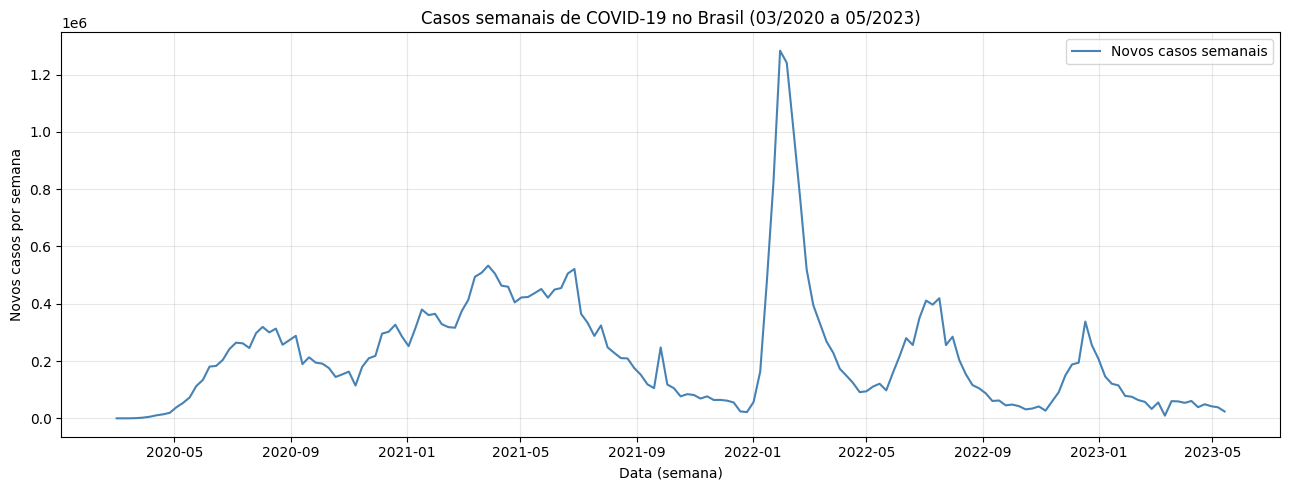

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 5))
plt.plot(serie_sem.index, serie_sem.values, color="steelblue",
         linewidth=1.5, label="Novos casos semanais")

plt.title("Casos semanais de COVID-19 no Brasil (03/2020 a 05/2023)")
plt.xlabel("Data (semana)")
plt.ylabel("Novos casos por semana")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("grafico1_serie_original.png", dpi=150)  # salva para o relatório
plt.show()

**Análise visual da série**


*Existe uma tendência de crescimento ou queda?*


Não há uma tendência única ao longo de toda a série. O comportamento predominante é de ondas sucessivas: pelo menos quatro picos são visíveis (metade de 2020, primeiro semestre de 2021, início de 2022 e metade/final de 2022), cada um seguido de queda. Comparando o início e o fim da série, o nível geral de casos semanais é mais baixo em 2023 do que nos picos de 2021 e 2022, o que sugere uma tendência de queda no longo prazo. No entanto, o meio da série é dominado pelas ondas, e não por uma trajetória linear de crescimento ou queda.

*Existem períodos de estabilidade?*


Sim. Aparecem trechos relativamente estáveis e com valores baixos entre as ondas, como o final de 2020 (antes da onda de início de 2021), o final de 2021 (antes da chegada da Ômicron) e o período a partir de metade de 2023, quando a série se mantém baixa e quase sem oscilação até o fim dos dados.

*Existem oscilações frequentes?*


Sim. Dentro de cada onda, a linha sobe e desce em pequenas variações, formando um padrão "serrilhado", e não uma curva perfeitamente lisa. Isso é esperado mesmo com dados semanais, já que a notificação de casos ainda varia de uma semana para outra.

*Existem variações abruptas?*


Sim, a mais evidente é a virada de dezembro de 2021 para janeiro de 2022: a série sai de um nível baixo (próximo de 0,1 milhão de casos por semana) e sobe rapidamente até o pico de cerca de 1,28 milhão de casos por semana, em poucas semanas. É a subida mais rápida e mais acentuada de toda a série.

*Há algum período que se destaque dos demais?*


Sim, o pico do início de 2022 se destaca claramente dos demais. Ele é mais que o dobro da altura de qualquer outro pico da série (os demais ficam entre 0,3 e 0,5 milhão de casos por semana), o que o torna facilmente identificável no gráfico. Esse pico corresponde à chegada da variante Ômicron do SARS-CoV-2 ao Brasil, identificada por apresentar maior transmissibilidade em relação às variantes anteriores, o que explica o crescimento rápido e acentuado de casos no período.



**Estatísticas da série completa**

In [ ]:
media = serie_sem.mean()
mediana = serie_sem.median()
desvio = serie_sem.std()

print(f"Média:         {media:,.2f} casos/semana")
print(f"Mediana:       {mediana:,.2f} casos/semana")
print(f"Desvio padrão: {desvio:,.2f} casos/semana")
print(f"Mínimo:        {serie_sem.min():,.2f}")
print(f"Máximo:        {serie_sem.max():,.2f}")

Média:         223,285.24 casos/semana
Mediana:       181,822.00 casos/semana
Desvio padrão: 204,310.31 casos/semana
Mínimo:        1.00
Máximo:        1,283,024.00


Considerando toda a série (168 semanas, de 01/03/2020 a 14/05/2023), a média de novos casos foi de 223.285,24 casos/semana, a mediana foi de 181.822,00 casos/semana, e o desvio padrão foi de 204.310,31 casos/semana. O valor mínimo registrado foi de 1,00 caso/semana e o máximo foi de 1.283.024,00 casos/semana.
A média é bem maior que a mediana, o que indica uma distribuição assimétrica à direita: a maior parte das semanas apresentou valores moderados ou baixos, enquanto um pequeno número de semanas de pico, sobretudo a onda da Ômicron no início de 2022, teve valores muito acima do restante da série e "puxou" a média para cima. O desvio padrão (204.310,31) é quase do mesmo tamanho que a média (223.285,24), o que confirma a grande dispersão dos dados: a série alterna entre períodos de baixa transmissão, com poucas centenas ou milhares de casos por semana, e picos de mais de um milhão de casos, muito acima do padrão típico.



**Divisão da série em duas partes**

In [ ]:
meio = len(serie_sem) // 2

primeira_metade = serie_sem.iloc[:meio]
segunda_metade = serie_sem.iloc[meio:]

print("Total de semanas:", len(serie_sem))
print("\n1ª metade:", len(primeira_metade), "semanas")
print("Período:", primeira_metade.index.min().date(), "a", primeira_metade.index.max().date())

print("\n2ª metade:", len(segunda_metade), "semanas")
print("Período:", segunda_metade.index.min().date(), "a", segunda_metade.index.max().date())

Total de semanas: 168

1ª metade: 84 semanas
Período: 2020-03-01 a 2021-10-03

2ª metade: 84 semanas
Período: 2021-10-10 a 2023-05-14


**Média de cada metade**

In [ ]:
media_1 = primeira_metade.mean()
media_2 = segunda_metade.mean()

print(f"Média 1ª metade (01/03/2020 a 03/10/2021): {media_1:,.2f} casos/semana")
print(f"Média 2ª metade (10/10/2021 a 14/05/2023): {media_2:,.2f} casos/semana")

Média 1ª metade (01/03/2020 a 03/10/2021): 255,305.37 casos/semana
Média 2ª metade (10/10/2021 a 14/05/2023): 191,265.12 casos/semana


**Comparação entre as duas médias**

In [ ]:
diferenca = media_2 - media_1
variacao_pct = (diferenca / media_1) * 100

print(f"Média 1ª metade: {media_1:,.2f} casos/semana")
print(f"Média 2ª metade: {media_2:,.2f} casos/semana")
print(f"Diferença (2ª - 1ª): {diferenca:,.2f} casos/semana")
print(f"Variação: {variacao_pct:.1f}%")

Média 1ª metade: 255,305.37 casos/semana
Média 2ª metade: 191,265.12 casos/semana
Diferença (2ª - 1ª): -64,040.25 casos/semana
Variação: -25.1%


Comparando as duas médias, observa-se que a média de casos semanais caiu de 255.305,37 na primeira metade da série para 191.265,12 na segunda metade, uma redução de aproximadamente 64.040 casos/semana, o que representa uma queda de cerca de 25,1%.

Esse resultado sugere que, em média, o nível de casos foi mais baixo na segunda metade do período analisado. No entanto, essa diferença deve ser interpretada com cuidado: como vimos no item 5, a série é composta por ondas sucessivas, e não por uma tendência constante. A primeira metade (03/2020 a 10/2021) inclui as duas primeiras ondas da pandemia, com picos relativamente altos e sustentados por vários meses. Já a segunda metade (10/2021 a 05/2023) inclui o pico mais alto de toda a série (a onda da Ômicron, em janeiro de 2022), mas também um período final bastante longo e estável, com valores baixos (metade de 2022 em diante). Ou seja, a média mais baixa da segunda metade reflete mais a extensão do período de baixa transmissão no final da série do que uma ausência de picos altos nesse intervalo.

**Discussão: mudança no comportamento da variável ao longo do tempo**

O comportamento da variável parece ter mudado ao longo do tempo, mas essa mudança não foi uma queda linear e constante — ela envolveu principalmente uma alteração no padrão das ondas.

Justificativa com base nos números: a média de casos semanais caiu 25,1% da primeira metade da série (255.305 casos/semana) para a segunda metade (191.265 casos/semana). Além disso, a mediana de toda a série (181.822) ficou abaixo da média (223.285), o que já indicava, desde o item 6, uma distribuição assimétrica, com poucos períodos de valores muito altos.

Justificativa com base no gráfico: o gráfico de linha mostra que essa redução na média não veio de uma diminuição progressiva de casos. O pico mais alto de toda a série, correspondente à onda da Ômicron, está dentro da segunda metade (início de 2022), e não da primeira. O que reduziu a média da segunda metade foi o longo período final, de metade de 2022 a maio de 2023, com valores baixos e estáveis.

Conclusão: a mudança real no comportamento da variável não foi "menos casos com o tempo", mas sim uma transição de um padrão de ondas sucessivas e sustentadas (primeira metade) para um padrão de ondas ainda intensas, porém seguidas por períodos de baixa e estabilidade mais longos (segunda metade). Isso é compatível com o avanço da vacinação e o acúmulo de imunidade da população ao longo da pandemia. Olhar só a média levaria a uma conclusão equivocada de melhora constante, quando na verdade a série contém, na sua segunda metade, o momento mais grave de toda a pandemia.

**Aplicação da média móvel**

In [ ]:
JANELA = 4  # 4 semanas ≈ 1 mês

media_movel = serie_sem.rolling(window=JANELA).mean()

print(f"Média móvel de {JANELA} semanas (primeiras linhas):")
print(media_movel.head(8))

print(f"\nMédia móvel de {JANELA} semanas (últimas linhas):")
print(media_movel.tail())

Média móvel de 4 semanas (primeiras linhas):
date
2020-03-01        NaN
2020-03-08        NaN
2020-03-15        NaN
2020-03-22     226.00
2020-03-29     854.00
2020-04-05    2260.75
2020-04-12    4888.50
2020-04-19    8194.50
Freq: W-SUN, Name: new_cases, dtype: float64

Média móvel de 4 semanas (últimas linhas):
date
2023-04-16    53144.50
2023-04-23    50638.75
2023-04-30    47688.75
2023-05-07    42179.25
2023-05-14    38457.25
Freq: W-SUN, Name: new_cases, dtype: float64


Foi aplicada uma média móvel com janela de 4 semanas (equivalente a aproximadamente um mês) sobre a série de novos casos semanais. Essa técnica substitui cada valor pela média das 4 semanas mais recentes (incluindo a própria), suavizando oscilações de curto prazo e tornando mais visível o padrão geral de subida e queda das ondas.

Como consequência do método, as três primeiras semanas da série ficam sem valor de média móvel, já que não há semanas anteriores suficientes para o cálculo. No início da série, a média móvel mostra o crescimento inicial dos casos (de 226 para mais de 8.000 casos/semana em poucas semanas), refletindo a fase inicial de disseminação do vírus no país. Já no final da série, a média móvel mostra uma queda gradual (de cerca de 53.000 para 38.000 casos/semana), compatível com o período de baixa transmissão observado no gráfico.

**Justificativa da janela escolhida**

A janela de 4 semanas foi escolhida por representar aproximadamente um mês, um intervalo curto o suficiente para acompanhar de perto a evolução das ondas de COVID-19, mas longo o suficiente para suavizar as oscilações semana a semana que aparecem mesmo em dados já agregados semanalmente (como visto no item 5, "oscilações frequentes").

Uma janela menor, como 2 semanas, suavizaria pouco e a curva ainda ficaria bastante "serrilhada". Já uma janela maior, como 8 ou 12 semanas, atrasaria demais a resposta da média móvel às mudanças reais da série, achatando picos importantes (como o da Ômicron) e dificultando a identificação do início e do fim de cada onda. A janela de 4 semanas, portanto, equilibra a suavização das oscilações de curto prazo com a preservação do formato das ondas, que é o comportamento mais relevante desta série.

**Gráfico com série original e média móvel**

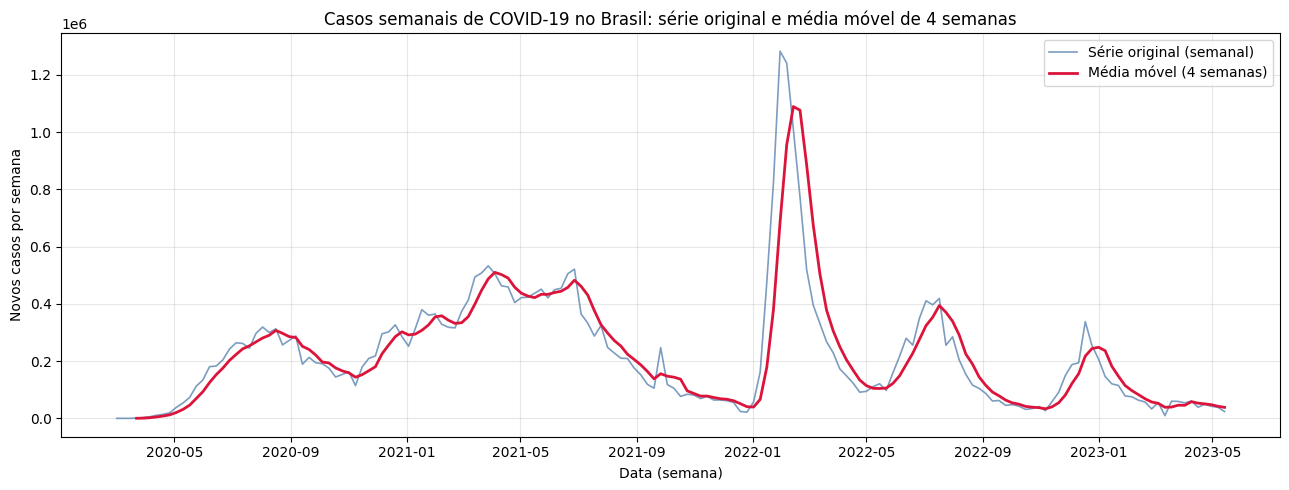

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 5))
plt.plot(serie_sem.index, serie_sem.values, color="#5B84B1",
         linewidth=1.2, alpha=0.8, label="Série original (semanal)")
plt.plot(media_movel.index, media_movel.values, color="crimson",
         linewidth=2, label="Média móvel (4 semanas)")

plt.title("Casos semanais de COVID-19 no Brasil: série original e média móvel de 4 semanas")
plt.xlabel("Data (semana)")
plt.ylabel("Novos casos por semana")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("grafico2_media_movel.png", dpi=150)
plt.show()

**Comparação entre as duas curvas**

*Quais oscilações foram suavizadas?*

A média móvel suavizou principalmente as pequenas variações semana a semana dentro de cada onda, os "dentes" que aparecem na série original ao longo das subidas e descidas. Isso fica visível, por exemplo, nas oscilações entre 2020-09 e 2021-01 e entre 2022-05 e 2022-09, onde a linha vermelha corre mais lisa que a azul. A suavização mais marcante ocorre no topo do pico da Ômicron (início de 2022): a série original chega a quase 1,3 milhão de casos em uma única semana, enquanto a média móvel atinge um valor máximo bem menor, pouco acima de 1,1 milhão, "cortando" o topo mais agudo do pico.

*A média móvel tornou alguma tendência mais evidente?*

Sim. Com as pequenas oscilações removidas, fica mais fácil identificar o início e o fim de cada onda, assim como os períodos de estabilidade entre elas. A trajetória geral de subida, pico e queda de cada ciclo epidêmico aparece de forma mais limpa na curva vermelha, o que facilita a leitura visual do comportamento da série ao longo do tempo, especialmente para quem não está acostumado a interpretar dados ruidosos.

*Existem comportamentos importantes que ficaram menos visíveis depois da suavização?*

Sim, principalmente a altura real do pico máximo. Como a janela de 4 semanas calcula uma média, ela reduz a magnitude do valor mais alto da série, o que pode levar a subestimar a gravidade do momento mais crítico da pandemia (a semana de maior número de casos) caso alguém olhe apenas para a média móvel. Também ficam menos visíveis picos semanais isolados e mais curtos, que podem sinalizar eventos pontuais (como atraso de notificação seguido de acúmulo em uma única semana), já que eles são diluídos na média das semanas vizinhas.

**Período com variação acentuada**

O período escolhido é a virada de dezembro de 2021 para janeiro/fevereiro de 2022, correspondente à chegada da variante Ômicron ao Brasil. Nesse intervalo, a série sai de um patamar baixo, próximo de 0,1 milhão de casos por semana, e sobe rapidamente até o valor máximo de toda a série, cerca de 1,28 milhão de casos por semana, em poucas semanas. A maior variação entre semanas consecutivas de toda a série ocorreu justamente nesse trecho: na semana de 30/01/2022, o número de casos aumentou em 458.445 casos em relação à semana anterior, o salto mais acentuado de todo o período analisado, muito acima da variação típica observada entre semanas vizinhas em outros trechos do gráfico.



In [ ]:
import pandas as pd

variacao = serie_sem.diff()
semana_maior_alta = variacao.idxmax()

print("Semana de maior alta:", semana_maior_alta.date())
print("Variação:", f"{variacao[semana_maior_alta]:,.2f} casos")

Semana de maior alta: 2022-01-30
Variação: 458,445.00 casos


**O que ocorreu no trecho de maior variação:**


Nesse trecho, entre dezembro de 2021 e o início de fevereiro de 2022, o número de casos semanais de COVID-19 no Brasil cresceu de forma extremamente rápida, saindo de um patamar relativamente baixo e estável (próximo de 0,1 milhão de casos/semana, mantido desde outubro de 2021) até o maior valor de toda a série, cerca de 1,28 milhão de casos na semana de 30/01/2022. Só entre essa semana e a anterior, o aumento foi de 458.445 casos, o maior salto observado em toda a série analisada.

Esse comportamento coincide com a chegada e a rápida disseminação da variante Ômicron do SARS-CoV-2 no Brasil, identificada por sua elevada transmissibilidade em relação às variantes anteriores. Mesmo com parte da população já vacinada, a variante conseguiu se espalhar de forma muito mais veloz que as ondas anteriores, o que explica por que o crescimento de casos nesse trecho foi tão mais abrupto do que em qualquer outro momento da pandemia registrado na série.

Esse período chamou atenção por dois motivos. Primeiro, pela velocidade do crescimento: nenhuma outra onda da série levou tão poucas semanas para sair de um nível baixo e atingir o pico. Segundo, pela magnitude: o valor máximo atingido nessa onda é mais que o dobro da altura de qualquer outro pico da série (os demais picos ficam entre 0,3 e 0,5 milhão de casos/semana), tornando esse trecho um ponto fora do padrão geral de comportamento da variável, mesmo quando comparado a outros momentos críticos da pandemia.



**A média móvel seria suficiente para prever valores futuros?**

Não. A média móvel é uma ferramenta útil para descrever e suavizar o comportamento passado da série, mas não é adequada para prever os valores futuros de casos de COVID-19, por alguns motivos observados ao longo da análise.
Ela apenas repete o passado recente, sem antecipar mudanças. Por construção, a média móvel calcula a média das últimas semanas, o que significa que ela sempre "olha para trás". Quando a série muda de direção de forma abrupta, como na virada de dezembro de 2021 para janeiro de 2022 (item 15 e 16), a média móvel só reflete essa mudança depois que ela já aconteceu, com um atraso, e não é capaz de antecipar que uma nova onda está prestes a começar.
A série tem um comportamento de ondas, não de tendência estável. Como discutido no item 5 e no item 10, a série não segue uma trajetória previsível de crescimento ou queda constante: ela alterna entre picos e vales de intensidade muito variável, influenciados por fatores externos ao histórico da própria série, como o surgimento de novas variantes (caso da Ômicron), mudanças no comportamento da população, campanhas de vacinação e alterações nas medidas de restrição. A média móvel não incorpora nenhuma dessas informações, apenas os valores numéricos passados da própria variável.
A magnitude dos picos é imprevisível a partir do padrão histórico. O item 14 mostrou que a média móvel chega a subestimar a altura real dos picos, já que ela "acha uma média" com as semanas vizinhas. Isso significa que, mesmo dentro de uma mesma onda, a média móvel não teria como estimar corretamente o valor máximo que seria atingido, muito menos prever a chegada de uma onda com magnitude mais que duas vezes maior que qualquer uma anterior, como foi a Ômicron.



**Conclusão**

A média móvel é adequada para descrever tendências de curto prazo e suavizar ruído, mas não é um método de previsão. Para projetar valores futuros de uma série como essa, marcada por eventos externos e mudanças estruturais de padrão, seriam necessários modelos mais robustos, que considerem sazonalidade, causas externas (como o surgimento de novas variantes) e, idealmente, dados epidemiológicos adicionais além do histórico da própria série de casos.
